## Day 8 — Linear Algebra I

## Part A — the curriculum activities

## TASK 01__Visualise 2D vectors and their arithmetic

In [ ]:

import matplotlib.pyplot as plt


# Helper function to draw 2D vectors
def draw_vectors(vector_list, vector_labels):
    figure, axes = plt.subplots(figsize=(5, 5))

    for vector, vector_label in zip(vector_list, vector_labels):
        axes.quiver(
            0, 0,
            vector[0], vector[1],
            angles='xy',
            scale_units='xy',
            scale=1
        )

        # Put label near the tip of the vector
        axes.text(
            vector[0],
            vector[1],
            vector_label,
            fontsize=12
        )

    axes.set_aspect('equal')
    axes.grid(alpha=0.3)

    # Set limits so vectors are clearly visible
    axes.set_xlim(-6, 6)
    axes.set_ylim(-6, 6)

    plt.show()


# 1. Draw three vectors

first_vector = [2, 3]
second_vector = [-3, 1]
third_vector = [4, -2]

draw_vectors(
    [first_vector, second_vector, third_vector],
    ['first vector', 'second vector', 'third vector']
)


# 2. Draw first vector, second vector and their sum

sum_vector = [
    first_vector[0] + second_vector[0],
    first_vector[1] + second_vector[1]
]

draw_vectors(
    [first_vector, second_vector, sum_vector],
    ['first vector', 'second vector', 'sum vector']
)

'''# Vector addition can be viewed tip-to-tail:
# place the tail of the second vector at the tip of the first vector.
# The vector from the original origin to the final tip
# represents the sum of the two vectors.'''


# 3. Draw first vector, twice the first vector and negative first vector

double_first_vector = [
    2 * first_vector[0],
    2 * first_vector[1]
]

opposite_first_vector = [
    -first_vector[0],
    -first_vector[1]
]

draw_vectors(
    [
        first_vector,
        double_first_vector,
        opposite_first_vector
    ],
    [
        'first vector',
        'double vector',
        'opposite vector'
    ]
)

'''# Scaling a vector by a positive number changes its length
# but keeps its direction.
# The double vector has twice the length of the first vector
# and the same direction.
# The opposite vector has the same length as the first vector
# but points in the opposite direction.'''


# 4. Draw first vector, second vector and their difference

difference_vector = [
    first_vector[0] - second_vector[0],
    first_vector[1] - second_vector[1]
]

draw_vectors(
    [
        first_vector,
        second_vector,
        difference_vector
    ],
    [
        'first vector',
        'second vector',
        'difference vector'
    ]
)

'''# Geometrically, the difference vector points
# from the tip of the second vector to the tip of the first vector.
#
# This is because:
#
# first vector - second vector
# = first vector + (-second vector)
#
# So subtracting the second vector means
# adding the opposite of the second vector.'''



##1. Why these `quiver` arguments?

```python
angles='xy'
scale_units='xy'
scale=1
```

* `angles='xy'` → arrow direction follows x-y coordinates.
* `scale_units='xy'` → arrow length uses x-y coordinate units.
* `scale=1` → keeps the vector's actual size.

#Without them:Matplotlib may scale the arrows differently, so their direction/length may not represent the actual vectors correctly.

---

##2. Negative scaling

```python
a = [2, 3]
-a = [-2, -3]
```

Negative scaling **reverses the direction** of the arrow.

```text
2a → same direction
-a → opposite direction
```

---

##3. `a - b` direction

**`a - b` points from `b` to `a`.**

```text
b ─────────→ a
     a - b
```

Because:

```text
b + (a - b) = a
```

So `a - b` is the displacement needed to move **from b to a**.


## TASK 02__Compute angles between vectors

In [2]:
import numpy as np


def calculate_angle_between_vectors(first_vector, second_vector):
    first_vector = np.array(first_vector)
    second_vector = np.array(second_vector)

    cosine_value = (
        first_vector @ second_vector) / (np.linalg.norm(first_vector)* np.linalg.norm(second_vector)
    )

    # Clip prevents floating-point errors from making cosine_value
    # slightly greater than 1 or less than -1.
    cosine_value = np.clip(cosine_value, -1, 1)

    angle_in_degrees = np.degrees(
        np.arccos(cosine_value)
        )

    return angle_in_degrees


# Known cases

perpendicular_first_vector = [1, 0]
perpendicular_second_vector = [0, 1]

print(
    calculate_angle_between_vectors(
        perpendicular_first_vector,
        perpendicular_second_vector
)) # 90°


same_direction_first_vector = [1, 2]
same_direction_second_vector = [1, 2]

print(
    calculate_angle_between_vectors(
        same_direction_first_vector,
        same_direction_second_vector
    )
)  # 0°


opposite_direction_first_vector = [1, 0]
opposite_direction_second_vector = [-1, 0]

print(
    calculate_angle_between_vectors(
        opposite_direction_first_vector,
        opposite_direction_second_vector
    )
)  # 180°


# Two students' exam-score vectors

first_student_scores = np.array([80, 75, 90, 85, 70])
second_student_scores = np.array([78, 72, 88, 84, 68])

students_score_angle = calculate_angle_between_vectors(
    first_student_scores,
    second_student_scores
)

print(students_score_angle)


90.0
1.2074182697257333e-06
180.0
0.5322067258925848


#1. Without `np.clip`, what can cosine reach?

Due to floating-point rounding, cosine value can become slightly outside `[-1, 1]`, e.g. `1.0000000001`. Since `arccos()` only accepts values from **-1 to 1**, it returns `nan`.

#2. Which day did you first meet this cosine formula?

You first met it in the **Vectors / Dot Product** topic. It is called the **cosine similarity / angle formula**:

$$
\cos\theta = \frac{a\cdot b}{|a||b|}
$$

#3. Why does scaling a vector leave every angle unchanged?

Scaling changes only the **length**, not the **direction** of a vector. Since angle depends on direction, multiplying a vector by a positive number does not change its angle.


## TASK 03__Implement Gram-Schmidt orthogonalisation

In [7]:
import numpy as np


def gram_schmidt(input_vectors):
    orthonormal_basis = []

    for current_vector in input_vectors:
        orthogonal_component = current_vector.astype(float).copy()

        # Remove the part of the vector that lies along
        # each basis vector found so far.
        for basis_vector in orthonormal_basis:
            orthogonal_component = (
                orthogonal_component - (current_vector @ basis_vector) * basis_vector
            )

        component_length = np.linalg.norm(orthogonal_component)

        # Skip vectors that are (almost) linearly dependent
        if component_length > 1e-10:
            orthonormal_basis.append(
                orthogonal_component / component_length
            )

    return np.array(orthonormal_basis)


# Three independent 3D vectors
independent_vectors = np.array([
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1]
], dtype=float)

orthonormal_matrix = gram_schmidt(independent_vectors)

print("Orthonormal basis:")
print(orthonormal_matrix)

print("\northonormal_matrix @ orthonormal_matrix.T:")
print(orthonormal_matrix @ orthonormal_matrix.T)

print("\nRank of input:", np.linalg.matrix_rank(independent_vectors))
print("Rank of orthonormal matrix:", np.linalg.matrix_rank(orthonormal_matrix))


# Dependent vectors
dependent_vectors = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [1, 1, 0]
], dtype=float)

dependent_orthonormal_matrix = gram_schmidt(dependent_vectors)

print("\nDependent input:")
print(dependent_orthonormal_matrix)

print("\nRank of dependent input:",
    np.linalg.matrix_rank(dependent_vectors))
print("Number of basis vectors:",
    len(dependent_orthonormal_matrix))


# Compare with NumPy QR
numpy_orthonormal_matrix, numpy_upper_triangular_matrix = np.linalg.qr(
    independent_vectors
)

print("\nOur orthonormal matrix:")
print(orthonormal_matrix)

print("\nNumPy orthonormal matrix:")
print(numpy_orthonormal_matrix)

print("\nOur matrix @ its transpose:")
print(orthonormal_matrix @ orthonormal_matrix.T)

print("\nNumPy matrix @ its transpose:")
print(numpy_orthonormal_matrix @ numpy_orthonormal_matrix.T)


Orthonormal basis:
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

orthonormal_matrix @ orthonormal_matrix.T:
[[ 1.00000000e+00  1.03018891e-16  1.51811967e-16]
 [ 1.03018891e-16  1.00000000e+00 -1.59104334e-16]
 [ 1.51811967e-16 -1.59104334e-16  1.00000000e+00]]

Rank of input: 3
Rank of orthonormal matrix: 3

Dependent input:
[[1. 0. 0.]
 [0. 1. 0.]]

Rank of dependent input: 2
Number of basis vectors: 2

Our orthonormal matrix:
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

NumPy orthonormal matrix:
[[-0.70710678  0.40824829 -0.57735027]
 [-0.70710678 -0.40824829  0.57735027]
 [-0.          0.81649658  0.57735027]]

Our matrix @ its transpose:
[[ 1.00000000e+00  1.03018891e-16  1.51811967e-16]
 [ 1.03018891e-16  1.00000000e+00 -1.59104334e-16]
 [ 1.51811967e-16 -1.59104334e-16  1.00000000e+00]]

NumPy matrix @ its transpose:
[[ 1.00000000e+00

1. Why does `Q @ Q.T = I` prove orthonormality?

   * Diagonal = 1: each vector has length 1.
   * Off-diagonal = 0: vectors are perpendicular.
     Therefore, the vectors are **orthonormal**.

2. Why `norm > 1e-10` instead of `norm != 0`?

   Floating-point calculations can produce tiny values instead of exact zero. `1e-10` treats these tiny values as effectively zero.

3. Why can the basis differ from `np.linalg.qr()` only by a sign? Is it a real difference?

   A vector and its negative are both valid orthonormal vectors. So `[0.7, 0.7]` and `[-0.7, -0.7]` are not a meaningful mathematical difference.


## TASK 04__Prove that dot product zero means perpendicular

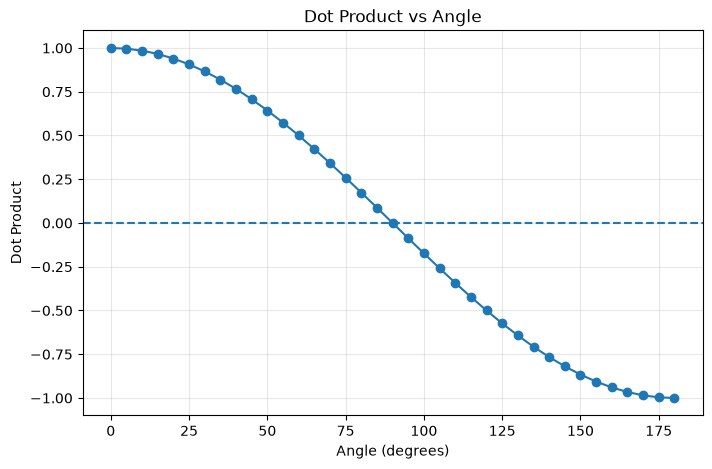

Angle: 90
Dot product: 6.123233995736766e-17


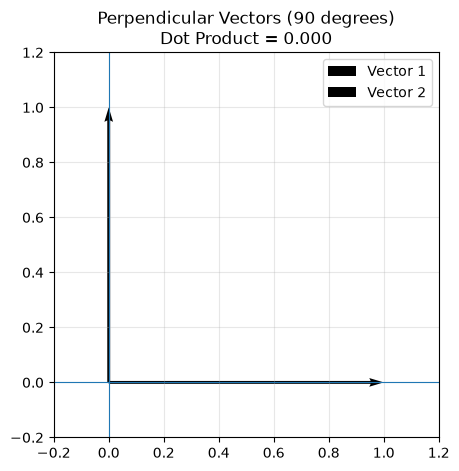

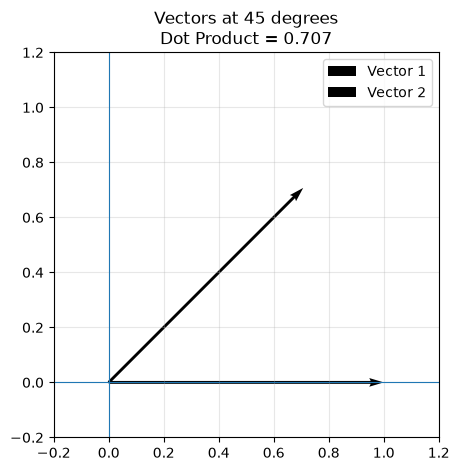

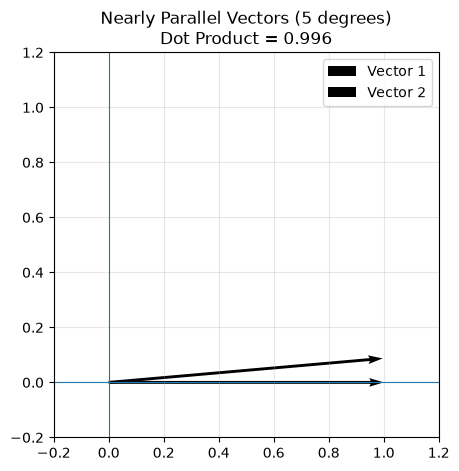

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Generate many vector pairs

angle_values = []
dot_product_values = []

base_vector = np.array([1.0, 0.0])

for angle_degrees in range(0, 181, 5):

    # Convert angle from degrees to radians
    angle_radians = np.radians(angle_degrees)

    # Create a unit vector at the given angle
    rotated_vector = np.array([
        np.cos(angle_radians),
        np.sin(angle_radians)
    ])

    # Calculate dot product
    dot_product = base_vector @ rotated_vector

    # Store the results
    angle_values.append(angle_degrees)
    dot_product_values.append(dot_product)



# 2. Plot dot product against angle

plt.figure(figsize=(8, 5))

plt.plot(
    angle_values,
    dot_product_values,
    marker='o'
)

# Show where dot product = 0
plt.axhline(0, linestyle='--')

plt.xlabel("Angle (degrees)")
plt.ylabel("Dot Product")
plt.title("Dot Product vs Angle")
plt.grid(alpha=0.3)

plt.show()

# Dot product crosses zero at 90 degrees.



# 3. Confirm the 90-degree case

for angle_degrees, dot_product in zip(
    angle_values,
    dot_product_values
):

    if angle_degrees == 90:

        print("Angle:", angle_degrees)
        print("Dot product:", dot_product)



# 4. Create three specific vector pairs

# Perpendicular vectors: 90 degrees
perpendicular_vector_1 = np.array([1.0, 0.0])
perpendicular_vector_2 = np.array([0.0, 1.0])


# Vectors at 45 degrees
forty_five_degree_vector_1 = np.array([1.0, 0.0])

forty_five_degree_vector_2 = np.array([
    np.cos(np.radians(45)),
    np.sin(np.radians(45))
])


# Nearly parallel vectors: 5 degrees
nearly_parallel_vector_1 = np.array([1.0, 0.0])

nearly_parallel_vector_2 = np.array([
    np.cos(np.radians(5)),
    np.sin(np.radians(5))
])



# 5. Function to draw two vectors

def draw_vector_pair(first_vector, second_vector, pair_title):

    plt.figure(figsize=(5, 5))

    # Draw first vector
    plt.quiver(
        0, 0,
        first_vector[0],
        first_vector[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        label="Vector 1"
    )

    # Draw second vector
    plt.quiver(
        0, 0,
        second_vector[0],
        second_vector[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        label="Vector 2"
    )

    # Calculate dot product
    dot_product = first_vector @ second_vector

    # Add title and dot product
    plt.title(
        f"{pair_title}\n"
        f"Dot Product = {dot_product:.3f}"
    )

    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)

    plt.grid(alpha=0.3)
    plt.legend()

    # Keep x and y scales equal
    plt.gca().set_aspect('equal')

    plt.show()



# 6. Draw the three vector pairs

draw_vector_pair(
    perpendicular_vector_1,
    perpendicular_vector_2,
    "Perpendicular Vectors (90 degrees)"
)


draw_vector_pair(
    forty_five_degree_vector_1,
    forty_five_degree_vector_2,
    "Vectors at 45 degrees"
)


draw_vector_pair(
    nearly_parallel_vector_1,
    nearly_parallel_vector_2,
    "Nearly Parallel Vectors (5 degrees)"
)



# 7. Explanation
\
# A zero dot product means cos(theta) = 0,
# because both vector lengths are non-zero.
# Since cos(90 degrees) = 0, the angle between
# the vectors must be 90 degrees.

1. At what angle does the dot-product curve cross zero?

   It crosses zero at **90°**, which matches the theory because \(\cos(90^\circ)=0\).

2. Why is the dot product positive below 90° and negative above?

   Below 90°, \(\cos(\theta)>0\), so the dot product is positive. Above 90°, \(\cos(\theta)<0\), so the dot product is negative.

3. Why does zero dot product mean 90°?
   Since

   $$
   \cos(\theta)=\frac{a\cdot b}{|a||b|}
   $$

   and both vectors are non-zero, \(a\cdot b=0\) makes \(\cos(\theta)=0\). Therefore, \(\theta=90^\circ\).


## Part B — apply the geometry

## TASK 05__Build a tiny search engine

In [9]:
import numpy as np


# 1. Vocabulary

vocabulary = ['ml', 'data', 'model', 'cook', 'recipe', 'food']


# 2. Five documents as word-count vectors
# Order: [ml, data, model, cook, recipe, food]

document_vectors = np.array([
    [8, 6, 4, 0, 0, 0],     # Document 1: ML
    [0, 1, 0, 7, 8, 6],     # Document 2: Cooking
    [7, 5, 3, 0, 0, 1],     # Document 3: ML
    [8, 6, 0, 6, 5, 4],     # Document 4: Different topic/mixed
    [40, 30, 20, 0, 0, 0]    # Document 5: Same ML topic, 5x longer
])

document_names = [
    "Document 1 - ML",
    "Document 2 - Cooking",
    "Document 3 - ML",
    "Document 4 - Mixed",
    "Document 5 - Long ML"
]


# 3. Query vector

query_vector = np.array([9, 7, 5, 0, 0, 0])



# 4. Function to calculate cosine similarity

def calculate_cosine_similarity(first_vector, second_vector):

    dot_product = first_vector @ second_vector

    first_vector_length = np.linalg.norm(first_vector)
    second_vector_length = np.linalg.norm(second_vector)

    cosine_similarity = (
        dot_product /
        (first_vector_length * second_vector_length)
    )

    return cosine_similarity


# 5. Calculate cosine similarity for all documents

cosine_similarity_scores = []

for document_vector in document_vectors:

    similarity_score = calculate_cosine_similarity(
        query_vector,
        document_vector
    )

    cosine_similarity_scores.append(similarity_score)



# 6. Rank documents: highest similarity first

cosine_ranking = np.argsort(
    cosine_similarity_scores
)[::-1]


print("Ranking using cosine similarity:")

for document_index in cosine_ranking:

    print(
        document_names[document_index],
        "->",
        round(cosine_similarity_scores[document_index], 3)
    )



# 7. Compare short and long ML documents

short_ml_document = document_vectors[0]
long_ml_document = document_vectors[4]

length_difference_similarity = calculate_cosine_similarity(
    short_ml_document,
    long_ml_document
)

print("\nShort ML vs Long ML cosine similarity:")
print(round(length_difference_similarity, 3))



# 8. Rank documents using raw dot product

dot_product_scores = []

for document_vector in document_vectors:

    dot_product = query_vector @ document_vector

    dot_product_scores.append(dot_product)


dot_product_ranking = np.argsort(
    dot_product_scores
)[::-1]


print("\nRanking using raw dot product:")

for document_index in dot_product_ranking:

    print(
        document_names[document_index],
        "->",
        dot_product_scores[document_index]
    )

Ranking using cosine similarity:
Document 5 - Long ML -> 0.999
Document 1 - ML -> 0.999
Document 3 - ML -> 0.99
Document 4 - Mixed -> 0.688
Document 2 - Cooking -> 0.046

Short ML vs Long ML cosine similarity:
1.0

Ranking using raw dot product:
Document 5 - Long ML -> 670
Document 1 - ML -> 134
Document 4 - Mixed -> 114
Document 3 - ML -> 113
Document 2 - Cooking -> 7


1. When does raw dot product rank differently from cosine? Which is right?

   Raw dot product can favor **longer documents** because they have larger values. Cosine is better when we want to compare **topic/pattern similarity independent of length**.

2. What is the cosine of a document with itself? Why?

   It is **1**, because a vector has the same direction as itself:

   $$
   \cos(0^\circ)=1
   $$

3. What if vectors came from a neural network instead of word counts?

   The same cosine formula can be used. Neural networks produce **embeddings** that capture features or meaning, so cosine similarity can measure how semantically similar two items are.


## TASK 06__Detect redundant features

In [10]:
import numpy as np


# 1. Create a dataset with 5 features
# height_inches is perfectly dependent on height_cm

feature_matrix = np.array([
    [170, 66.93, 65, 55, 22],
    [175, 68.90, 70, 60, 25],
    [180, 70.87, 75, 65, 28],
    [165, 64.96, 60, 50, 20],
    [185, 72.83, 80, 70, 30]
])

feature_names = [
    "height_cm",
    "height_inches",
    "weight_kg",
    "age",
    "experience_years"
]


# 2. Calculate the rank of the feature matrix

original_rank = np.linalg.matrix_rank(feature_matrix)

print("Original rank:", original_rank)

'''Why is the rank less than 5?

height_inches is just a fixed multiple of height_cm:

$$ height\_inches = \frac{height\_cm}{2.54} $$

So these two features provide essentially the same information. 
Therefore, the 5 columns do not contain 5 independent pieces of information.'''


#3. Check correlations

correlation_matrix = np.corrcoef(feature_matrix.T)

print("\nCorrelation matrix:")
print(correlation_matrix)


'''.T transposes the matrix so that each feature becomes a variable for np.corrcoef().

You will see that height_cm and height_inches have correlation very close to:

1.0

This indicates they are perfectly positively correlated.'''


# 4. Remove the redundant feature

reduced_feature_matrix = np.delete(
    feature_matrix,
    1,
    axis=1
)

Here:

'''1 means remove column index 1.
Column index 1 is height_inches.
axis=1 means we are removing a column, not a row.'''


#5. Check the new rank
reduced_rank = np.linalg.matrix_rank(reduced_feature_matrix)

print("\nRank after removing height_inches:", reduced_rank)


'''Now the rank should be: 4
because we have 4 independent features.'''

<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
C:\Users\KULDEEP\AppData\Local\Temp\ipykernel_30780\33167903.py:34: SyntaxWarning: invalid escape sequence '\_'
  $$ height\_inches = \frac{height\_cm}{2.54} $$


SyntaxError: invalid syntax (33167903.py, line 65)

Q1. What does `matrix_rank` return for your 5-feature matrix, and why is it not 5?

**Ans:** `matrix_rank` returns **4** because two features (`height_cm` and `height_inches`) are linearly dependent.

Q2. How is "linearly dependent features" related to "perfectly correlated features"?

**Ans:** Perfectly correlated features have an exact linear relationship, so one can be derived from the other.
Q3. Why do redundant features break linear regression but bother tree-based models less?

**Ans:** Redundant features cause **multicollinearity** in linear regression, making coefficients unstable. Tree models are less affected because they choose features through separate splits.
